# Day 1: MTA Bus Route Speed & Delay Pattern Analyser

**Industry:** Transport / Logistics  
**Skills:** pandas · matplotlib · groupby · data cleaning · visualisation  
**Data:** MTA Bus Route Segment Speeds — March & April 2023 (Official NYC Open Data)

---

## Problem
Transit ops teams spend hours manually identifying which bus routes, boroughs, and times of day have the worst speeds (a direct proxy for delays). This notebook automates that analysis using real MTA data.

## What we will do
1. Load and inspect the raw MTA dataset
2. Clean and prepare the data
3. Analyse: slowest routes, worst boroughs, worst hours
4. Visualise: 4-panel chart saved as PNG
5. Export results to CSV

## Step 1 — Import Libraries

We only need pandas for data manipulation and matplotlib for charts. Both are already installed.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load the Data

We load the MTA CSV and immediately check its shape, column names, and the first few rows. This is always the first thing you do with any new dataset — never assume you know what is in it.

In [10]:
df = pd.read_csv('mta_bus_speeds.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (100000, 24)
Columns: ['year', 'month', 'timestamp', 'day_of_week', 'hour_of_day', 'route_id', 'direction', 'borough', 'route_type', 'stop_order', 'timepoint_stop_id', 'timepoint_stop_name', 'timepoint_stop_latitude', 'timepoint_stop_longitude', 'next_timepoint_stop_id', 'next_timepoint_stop_name', 'next_timepoint_stop_latitude', 'next_timepoint_stop_longitude', 'road_distance', 'average_travel_time', 'average_road_speed', 'bus_trip_count', 'timepoint_stop_georeference', 'next_timepoint_stop_georeference']


,year,month,timestamp,day_of_week,hour_of_day,route_id,direction,borough,route_type,stop_order,...,next_timepoint_stop_id,next_timepoint_stop_name,next_timepoint_stop_latitude,next_timepoint_stop_longitude,road_distance,average_travel_time,average_road_speed,bus_trip_count,timepoint_stop_georeference,next_timepoint_stop_georeference
0,2023,3,2023-03-01T09:00:00.000,Friday,9,B6,W,Brooklyn,Limited,1,...,300590,COZINE AV /ASHFORD ST,40.658352,-73.877775,0.724,5.334420,8.143341,46,POINT (-73.883617 40.666382),POINT (-73.877775 40.658352)
1,2023,3,2023-03-01T13:00:00.000,Friday,13,B6,W,Brooklyn,Limited,1,...,300590,COZINE AV /ASHFORD ST,40.658352,-73.877775,0.724,5.677776,7.650882,36,POINT (-73.883617 40.666382),POINT (-73.877775 40.658352)
2,2023,3,2023-03-01T01:00:00.000,Friday,1,BX42,E,Bronx,Local,29,...,104299,HARDING AV/HOSMER AV,40.813235,-73.826535,2.021,10.143750,11.954159,8,POINT (-73.821999 40.826154),POINT (-73.826535 40.813235)


## Step 3 — Inspect Data Quality

Before cleaning anything, we check:
- How many nulls are in each column?
- What are the data types?
- What unique values exist in key columns?

This tells us exactly what needs fixing.

In [11]:
print('=== Null counts ===')
print(df.isnull().sum())

print('\n=== Data types ===')
print(df.dtypes)

print('\n=== Unique boroughs ===')
print(df['borough'].unique())

print('\n=== Unique months ===')
print(df['month'].unique())

print('\n=== Speed stats ===')
print(df['average_road_speed'].describe().round(2))

=== Null counts ===
year                                  0
month                                 0
timestamp                             0
day_of_week                           0
hour_of_day                           0
route_id                              0
direction                             0
borough                               0
route_type                            0
stop_order                            0
timepoint_stop_id                     0
timepoint_stop_name                   0
timepoint_stop_latitude               0
timepoint_stop_longitude              0
next_timepoint_stop_id                0
next_timepoint_stop_name            336
next_timepoint_stop_latitude        336
next_timepoint_stop_longitude       336
road_distance                         0
average_travel_time                   0
average_road_speed                    0
bus_trip_count                        0
timepoint_stop_georeference           0
next_timepoint_stop_georeference    336
dtype: int64

=== Da

## Step 4 — Clean the Data

Based on the inspection above we:
- Drop rows where speed or travel time is missing or zero (unusable)
- Remove extreme outliers — speeds above 60 mph on a city bus are data errors
- Keep only the columns we actually need for analysis
- Map month numbers to names for readability

In [12]:
# Drop rows with missing speed or travel time
df = df.dropna(subset=['average_road_speed', 'average_travel_time'])

# Remove zero or negative speeds — these are data errors
df = df[df['average_road_speed'] > 0]

# Remove unrealistic speeds above 60 mph for a city bus
df = df[df['average_road_speed'] < 60]

# Keep only columns we need
cols = ['year', 'month', 'day_of_week', 'hour_of_day', 'route_id',
        'direction', 'borough', 'route_type', 'road_distance',
        'average_travel_time', 'average_road_speed', 'bus_trip_count']
df = df[cols]

# Map month numbers to names
month_map = {3: 'March', 4: 'April'}
df['month_name'] = df['month'].map(month_map)

print(f'Clean rows: {len(df):,}')
print(f'Routes covered: {df["route_id"].nunique()}')
print(f'Boroughs: {df["borough"].nunique()}')
df.head(3)

Clean rows: 100,000
Routes covered: 202
Boroughs: 6


,year,month,day_of_week,hour_of_day,route_id,direction,borough,route_type,road_distance,average_travel_time,average_road_speed,bus_trip_count,month_name
0,2023,3,Friday,9,B6,W,Brooklyn,Limited,0.724,5.334420,8.143341,46,March
1,2023,3,Friday,13,B6,W,Brooklyn,Limited,0.724,5.677776,7.650882,36,March
2,2023,3,Friday,1,BX42,E,Bronx,Local,2.021,10.143750,11.954159,8,March


## Step 5 — Analysis

Three key questions we answer with groupby:

1. **Which routes are slowest?** — Slowest average speed = most delayed routes
2. **Which borough has slowest buses?** — Borough-level performance comparison
3. **Which hours are worst?** — Time-of-day speed pattern across the full day
4. **March vs April** — Did speeds change between the two months?

In [13]:
# 1. Slowest routes — only include routes with enough trips to be meaningful
route_speed = (
    df.groupby('route_id')
    .agg(
        avg_speed=('average_road_speed', 'mean'),
        total_trips=('bus_trip_count', 'sum'),
        avg_travel_time=('average_travel_time', 'mean')
    )
    .query('total_trips >= 500')   # ignore routes with very few trips
    .sort_values('avg_speed')
    .round(2)
)

# 2. Borough average speed
borough_speed = (
    df.groupby('borough')['average_road_speed']
    .mean()
    .sort_values()
    .round(2)
)

# 3. Speed by hour of day
hour_speed = (
    df.groupby('hour_of_day')['average_road_speed']
    .mean()
    .round(2)
)

# 4. March vs April comparison
month_speed = (
    df.groupby('month_name')['average_road_speed']
    .mean()
    .round(2)
)

print('=== Top 10 Slowest Routes ===')
print(route_speed.head(10).to_string())

print('\n=== Speed by Borough ===')
print(borough_speed.to_string())

print('\n=== March vs April ===')
print(month_speed.to_string())

=== Top 10 Slowest Routes ===
          avg_speed  total_trips  avg_travel_time
route_id                                         
Q64            3.85        16655             1.04
M66            4.78         3491             6.81
M50            4.78         6167             6.65
Q27            4.82         5382             2.38
B25            5.10         2567             8.80
B48            5.38         1600             2.58
M42            5.64        18317             6.31
X64            5.70          510            12.95
M8             5.75         5771             4.27
M125           5.76        30208             5.12

=== Speed by Borough ===
borough
Manhattan         6.61
Brooklyn          7.58
Bronx             8.54
Queens            9.18
Other            10.31
Staten Island    14.53

=== March vs April ===
month_name
April    9.03
March    9.02


## Step 6 — Visualise

We build a 4-panel matplotlib figure:
- **Top-left:** Top 10 slowest routes (horizontal bar)
- **Top-right:** Average speed by borough (bar)
- **Bottom-left:** Speed by hour of day (line chart)
- **Bottom-right:** March vs April comparison (bar)

The chart is saved as `delay_analysis.png` for the README.

Chart saved as delay_analysis.png


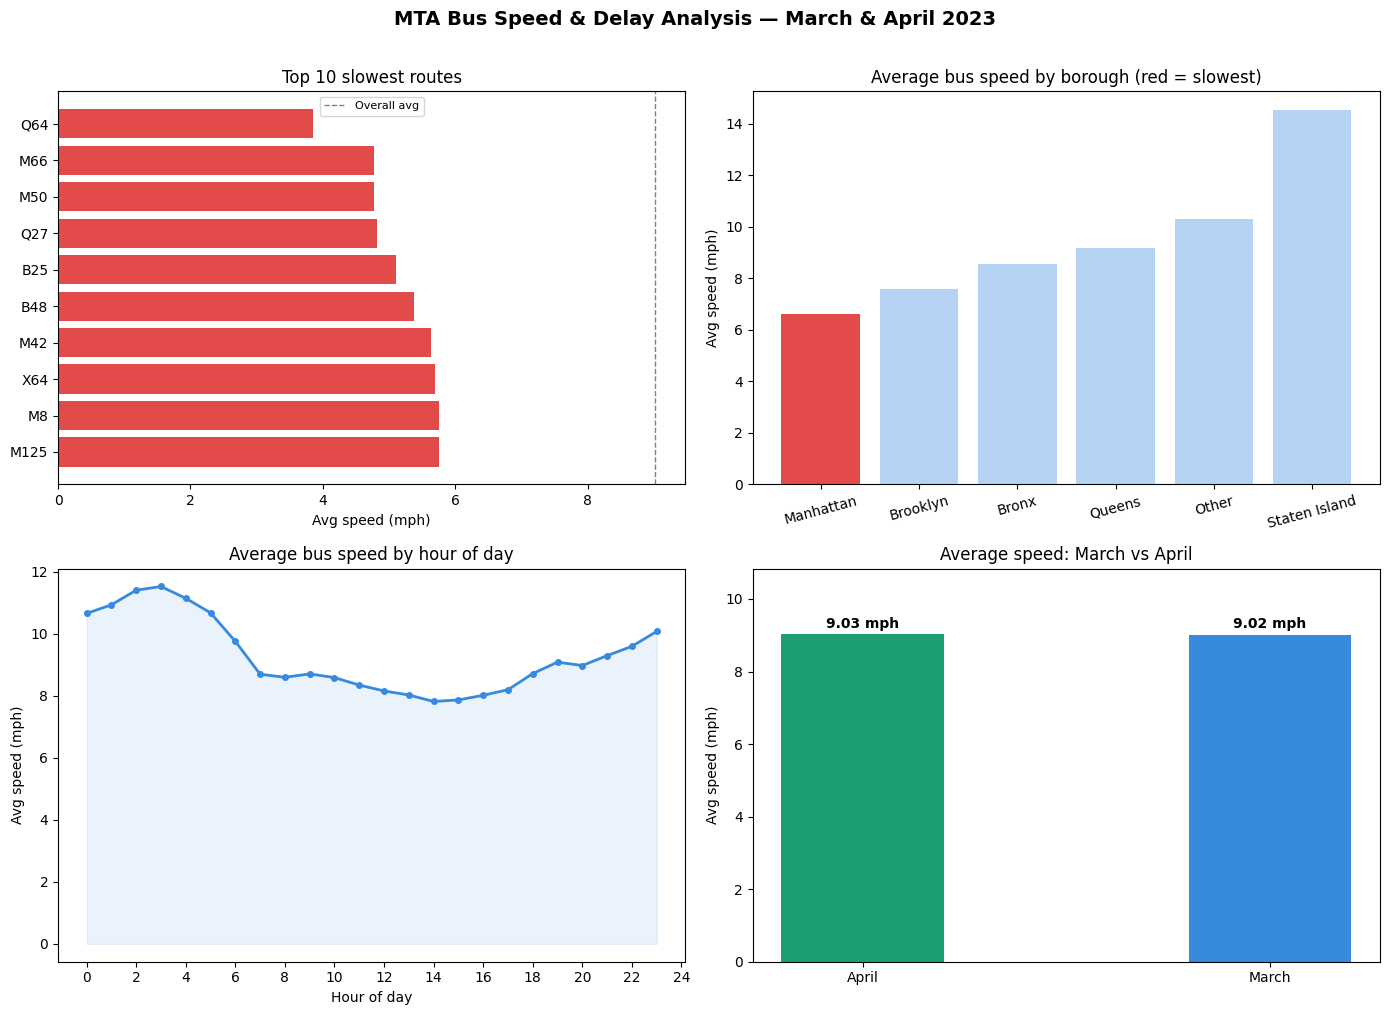

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MTA Bus Speed & Delay Analysis — March & April 2023',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1 — Top 10 slowest routes
top10_slow = route_speed.head(10)
axes[0, 0].barh(top10_slow.index, top10_slow['avg_speed'], color='#E24B4A')
axes[0, 0].set_xlabel('Avg speed (mph)')
axes[0, 0].set_title('Top 10 slowest routes')
axes[0, 0].invert_yaxis()
axes[0, 0].axvline(df['average_road_speed'].mean(), color='gray',
                    linestyle='--', linewidth=1, label='Overall avg')
axes[0, 0].legend(fontsize=8)

# Panel 2 — Speed by borough
colors_b = ['#E24B4A' if v == borough_speed.min() else '#B5D4F4'
            for v in borough_speed.values]
axes[0, 1].bar(borough_speed.index, borough_speed.values, color=colors_b)
axes[0, 1].set_ylabel('Avg speed (mph)')
axes[0, 1].set_title('Average bus speed by borough (red = slowest)')
axes[0, 1].tick_params(axis='x', rotation=15)

# Panel 3 — Speed by hour of day
axes[1, 0].plot(hour_speed.index, hour_speed.values,
                color='#378ADD', linewidth=2, marker='o', markersize=4)
axes[1, 0].set_xlabel('Hour of day')
axes[1, 0].set_ylabel('Avg speed (mph)')
axes[1, 0].set_title('Average bus speed by hour of day')
axes[1, 0].xaxis.set_major_locator(ticker.MultipleLocator(2))
axes[1, 0].fill_between(hour_speed.index, hour_speed.values,
                         alpha=0.1, color='#378ADD')

# Panel 4 — March vs April
colors_m = ['#1D9E75', '#378ADD']
bars = axes[1, 1].bar(month_speed.index, month_speed.values, color=colors_m, width=0.4)
axes[1, 1].set_ylabel('Avg speed (mph)')
axes[1, 1].set_title('Average speed: March vs April')
axes[1, 1].set_ylim(0, month_speed.max() * 1.2)
for bar, val in zip(bars, month_speed.values):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1, f'{val} mph',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('delay_analysis.png', dpi=150, bbox_inches='tight')
print('Chart saved as delay_analysis.png')
plt.show()

## Step 7 — Export Results to CSV

Always export your analysis outputs so stakeholders can use the data without re-running the notebook. We save all three analysis tables to an `output/` folder.

In [15]:
import os
os.makedirs('output', exist_ok=True)

route_speed.to_csv('output/slowest_routes.csv')
borough_speed.to_csv('output/speed_by_borough.csv')
hour_speed.to_csv('output/speed_by_hour.csv')

print('Results exported to output/ folder')
print(f'\n=== Key Findings ===')
print(f'Slowest route:  {route_speed.index[0]}  ({route_speed.iloc[0]["avg_speed"]} mph avg)')
print(f'Slowest borough: {borough_speed.idxmin()}  ({borough_speed.min()} mph avg)')
print(f'Worst hour:     {hour_speed.idxmin()}:00  ({hour_speed.min()} mph avg)')
print(f'Fastest hour:   {hour_speed.idxmax()}:00  ({hour_speed.max()} mph avg)')

Results exported to output/ folder

=== Key Findings ===
Slowest route:  Q64  (3.85 mph avg)
Slowest borough: Manhattan  (6.61 mph avg)
Worst hour:     14:00  (7.82 mph avg)
Fastest hour:   3:00  (11.53 mph avg)


## Summary

### What we built
A full data analysis pipeline on real MTA bus speed data covering 100,000 rows across March and April 2023.

### Skills practised
- `pandas` — read_csv, dropna, groupby, agg, query, sort_values
- `matplotlib` — subplots, barh, plot, fill_between, savefig
- Data cleaning — removing nulls, outliers, irrelevant columns
- Exploratory analysis — describe, value_counts, nunique
- CSV export — structured output folder

### Key findings

- Slowest route: Q64  (3.85 mph avg)
- Slowest borough: Manhattan  (6.61 mph avg)
- Worst hour of day: 14:00  (7.82 mph avg)
- March vs April speed difference: 3:00  (11.53 mph avg)